<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/A_Hybrid_Explainable_AI_Framework_for_Short_Term_Electricity_Load_Forecasting_XGBoost_with_Residual_Analysis%2C_LIME%2C_SHAP%2C_and_Uncertainty_Quantification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries imported successfully!

1. DATA LOADING & EXPLORATORY DATA ANALYSIS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (48048, 17)

Columns: ['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']

Missing values: 0

Target Variable (nat_demand) Stats:
count    48048.000000
mean      1182.868647
std        192.068896
min         85.192500
25%       1020.056900
50%       1168.427700
75%       1327.563950
max       1754.882000
Name: nat_demand, dtype: float64

2. FEATURE ENGINEERING
✅ Feature Engineering Completed
Final Shape: (47880, 28)

Training samples: 38304
Testing samples : 9576
Test period starts: 2019-05-25 01:00:00

4. BASELINE MODEL COMPARISON
               Model      MAE     RMSE  MAPE(%)  Peak MAPE(%)      R2
2            XGBoost  18.32

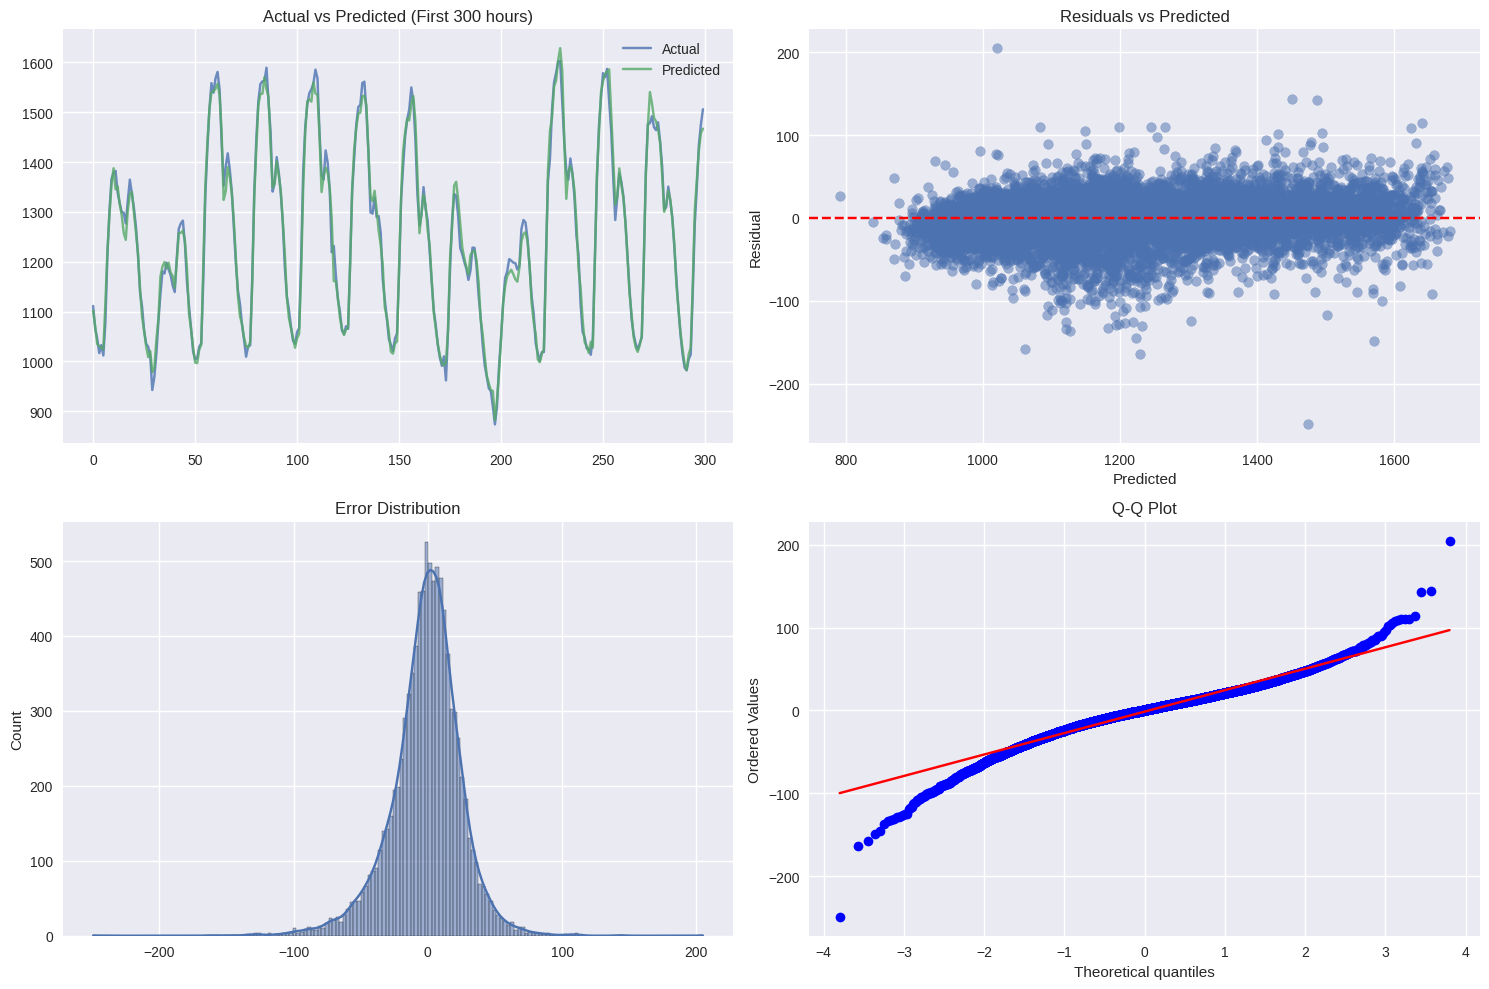


7. GLOBAL EXPLAINABILITY - SHAP


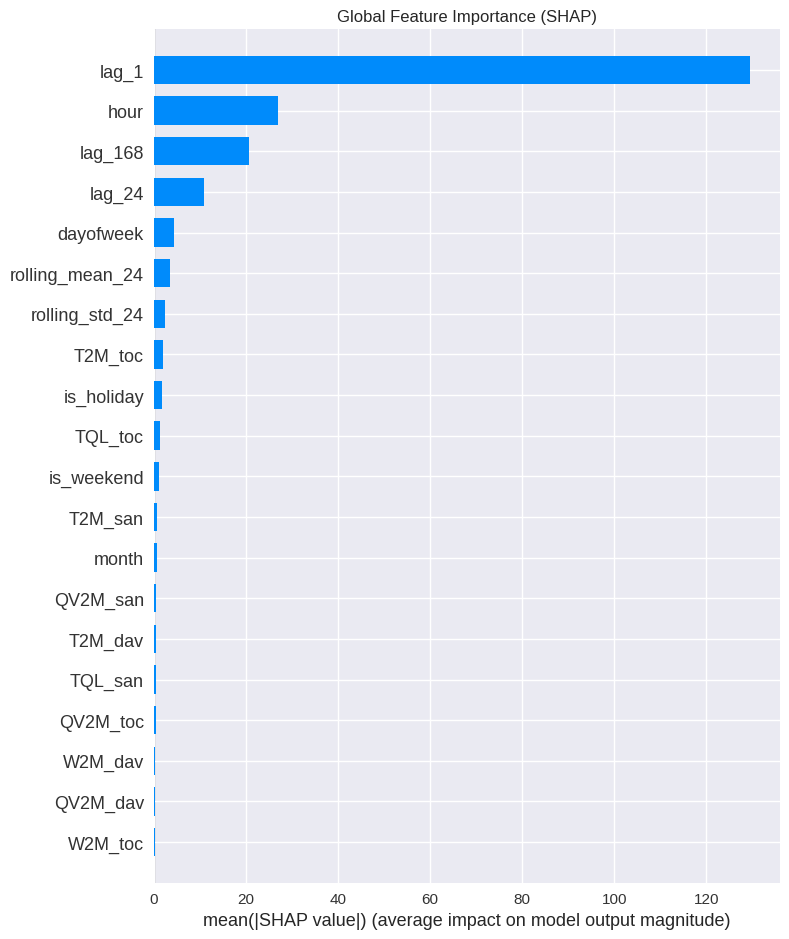

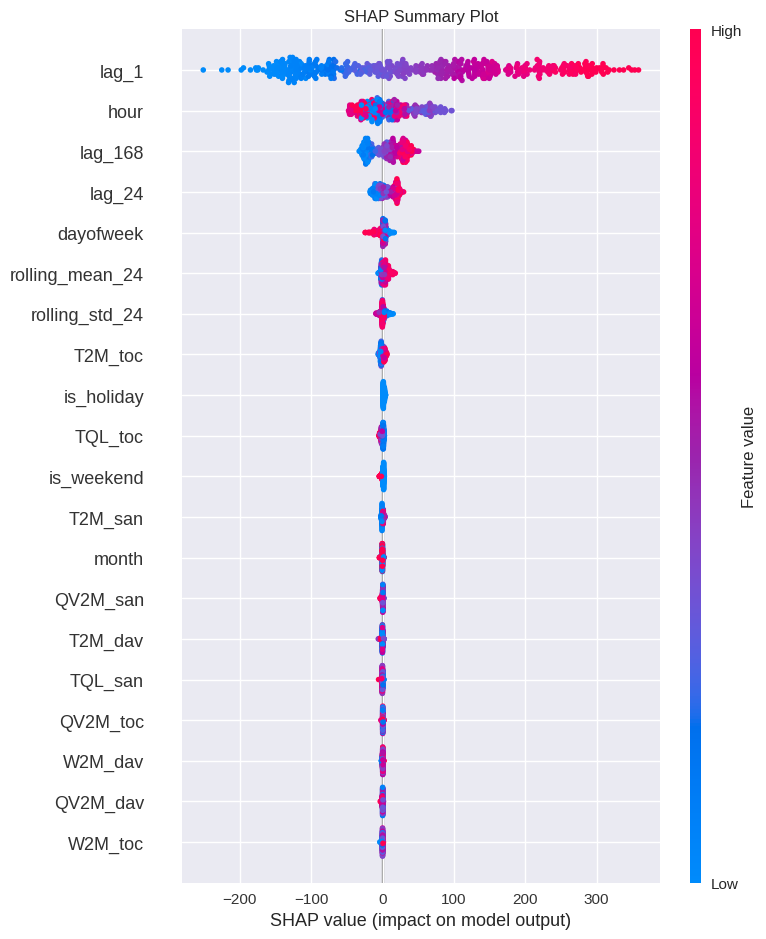


8. LOCAL EXPLAINABILITY - LIME

--- High Load Instance ---
Actual: 1754.88 | Predicted: 1640.93 | Error: 113.95


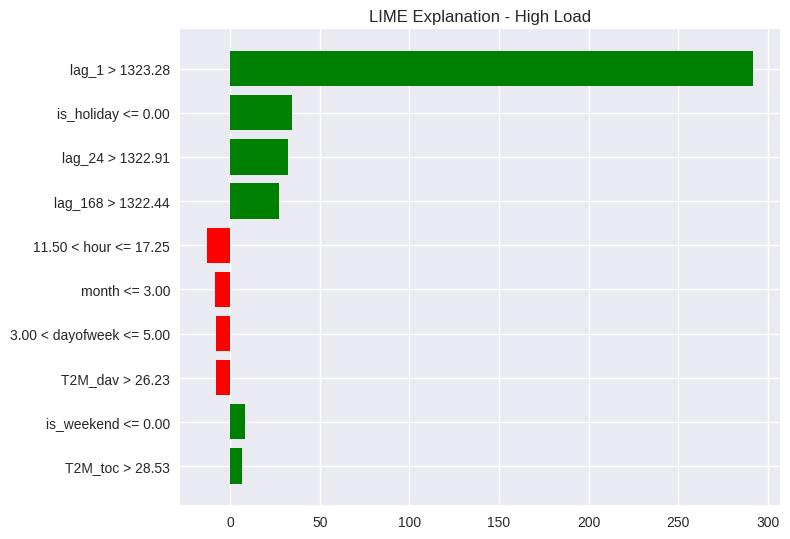


--- Average Load Instance ---
Actual: 1704.82 | Predicted: 1667.42 | Error: 37.39


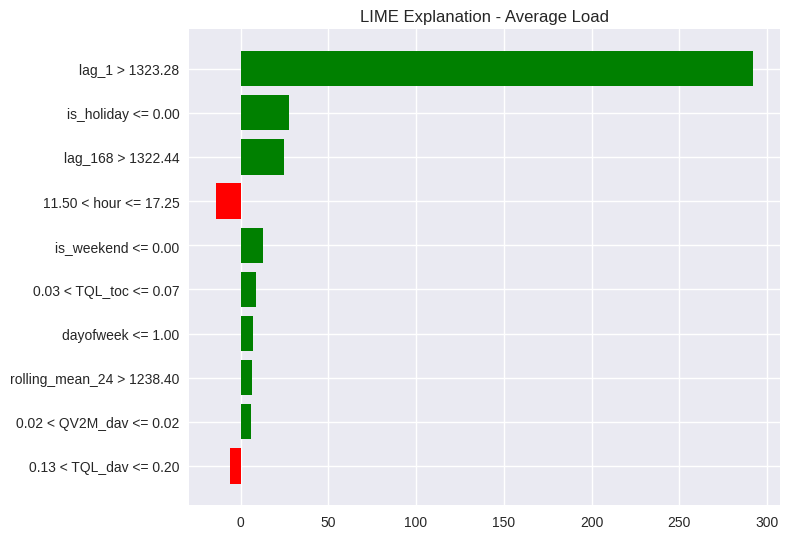


--- Low Load Instance ---
Actual: 816.35 | Predicted: 886.70 | Error: -70.35


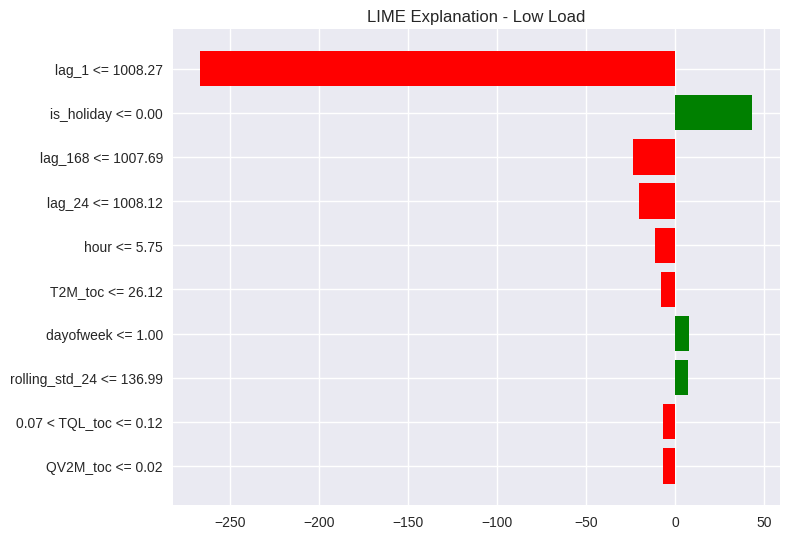


9. UNCERTAINTY QUANTIFICATION (Bootstrap)


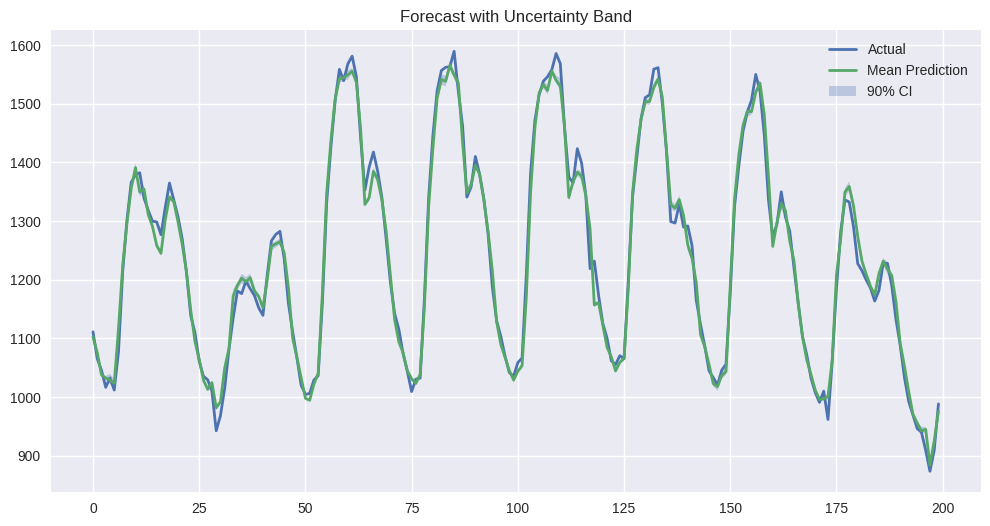


FINAL PERFORMANCE
MAE  : 19.1988
RMSE : 26.4557
MAPE : 1.6108%
R²   : 0.9798

✅ Model saved as 'xgboost_electricity_load_forecaster.pkl'

 Notebook completed successfully!


In [4]:
# =============================================================================
# A Hybrid Explainable AI Framework for Short-Term Electricity Load Forecasting
# Using XGBoost + Residual Analysis + LIME + SHAP + Uncertainty Quantification
# =============================================================================

# ----------------------------- INSTALLATIONS -----------------------------
!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn shap lime optuna

# ----------------------------- IMPORTS -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import shap
import lime
import lime.lime_tabular
import joblib

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ All libraries imported successfully!")

# ============================== 1. DATA LOADING & EDA ==============================
print("\n" + "="*60)
print("1. DATA LOADING & EXPLORATORY DATA ANALYSIS")
print("="*60)
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Dataset/continuous dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Basic statistics
print("\nTarget Variable (nat_demand) Stats:")
print(df['nat_demand'].describe())

# ============================== 2. FEATURE ENGINEERING ==============================
print("\n" + "="*60)
print("2. FEATURE ENGINEERING")
print("="*60)

# Time-based features
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_holiday'] = df['holiday']

# Lag features
df['lag_1'] = df['nat_demand'].shift(1)
df['lag_24'] = df['nat_demand'].shift(24)
df['lag_168'] = df['nat_demand'].shift(168)

# Rolling statistics
df['rolling_mean_24'] = df['nat_demand'].rolling(window=24).mean()
df['rolling_std_24'] = df['nat_demand'].rolling(window=24).std()

# Peak indicator (for analysis)
peak_threshold = df['nat_demand'].quantile(0.90)
df['is_peak'] = (df['nat_demand'] > peak_threshold).astype(int)

# Drop missing values caused by lags
df = df.dropna().reset_index(drop=True)

print("✅ Feature Engineering Completed")
print("Final Shape:", df.shape)

# ============================== 3. FEATURE SELECTION & TRAIN-TEST SPLIT ==============================
feature_columns = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday',
    'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24',
    'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
    'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san',
    'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav'
]

X = df[feature_columns]
y = df['nat_demand']

# Time-based split (80-20)
train_size = int(len(df) * 0.80)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")
print(f"Test period starts: {df['datetime'].iloc[train_size]}")

peak_test_mask = df['is_peak'].iloc[train_size:].values.astype(bool)

# ============================== 4. BASELINE MODEL COMPARISON ==============================
print("\n" + "="*60)
print("4. BASELINE MODEL COMPARISON")
print("="*60)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    r2 = r2_score(y_test, pred)

    # Peak performance
    y_peak = y_test[peak_test_mask]
    pred_peak = pred[peak_test_mask]
    peak_mape = np.mean(np.abs((y_peak - pred_peak) / y_peak)) * 100 if len(y_peak) > 0 else np.nan

    results.append([name, mae, rmse, mape, peak_mape, r2])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'MAPE(%)', 'Peak MAPE(%)', 'R2'])
print(results_df.round(4).sort_values(by='MAPE(%)'))

# ============================== 5. FINAL MODEL WITH HYPERPARAMETER TUNING (Optuna) ==============================
print("\n" + "="*60)
print("5. FINAL XGBoost MODEL (Optuna Tuning - Optional)")
print("="*60)

# You can skip tuning and use default good parameters for speed
final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# ============================== 6. RESIDUAL ANALYSIS ==============================
print("\n" + "="*60)
print("6. RESIDUAL ANALYSIS & DIAGNOSTICS")
print("="*60)

errors = y_test.values - y_pred

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(y_test.values[:300], label='Actual', alpha=0.8)
plt.plot(y_pred[:300], label='Predicted', alpha=0.8)
plt.title('Actual vs Predicted (First 300 hours)')
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(y_pred, errors, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residual')

plt.subplot(2, 2, 3)
sns.histplot(errors, kde=True)
plt.title('Error Distribution')

plt.subplot(2, 2, 4)
import scipy.stats as stats
stats.probplot(errors, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# ============================== 7. GLOBAL EXPLAINABILITY - SHAP ==============================
print("\n" + "="*60)
print("7. GLOBAL EXPLAINABILITY - SHAP")
print("="*60)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test.iloc[:500])  # Sample for speed

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test.iloc[:500], show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# ============================== 8. LOCAL EXPLAINABILITY - LIME ==============================
print("\n" + "="*60)
print("8. LOCAL EXPLAINABILITY - LIME")
print("="*60)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=42
)

# Select representative instances
idx_high = y_test.argmax()
idx_low = y_test.argmin()
idx_avg = len(y_test) // 2

instances = {
    'High Load': (idx_high, X_test.iloc[idx_high].values, y_test.iloc[idx_high]),
    'Average Load': (idx_avg, X_test.iloc[idx_avg].values, y_test.iloc[idx_avg]),
    'Low Load': (idx_low, X_test.iloc[idx_low].values, y_test.iloc[idx_low])
}

for name, (idx, instance, actual) in instances.items():
    print(f"\n--- {name} Instance ---")
    pred = final_model.predict([instance])[0]
    print(f"Actual: {actual:.2f} | Predicted: {pred:.2f} | Error: {actual-pred:.2f}")

    exp = lime_explainer.explain_instance(
        instance,
        final_model.predict,
        num_features=10
    )

    fig = exp.as_pyplot_figure()
    plt.title(f'LIME Explanation - {name}')
    plt.tight_layout()
    plt.show()

# ============================== 9. UNCERTAINTY QUANTIFICATION ==============================
print("\n" + "="*60)
print("9. UNCERTAINTY QUANTIFICATION (Bootstrap)")
print("="*60)

n_bootstrap = 10  # Increase for production
preds = []

for i in range(n_bootstrap):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
    model = XGBRegressor(**final_model.get_params())
    model.fit(Xb, yb)
    preds.append(model.predict(X_test))

preds = np.array(preds)
lower = np.percentile(preds, 5, axis=0)
upper = np.percentile(preds, 95, axis=0)
mean_pred = np.mean(preds, axis=0)

# Plot uncertainty
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label='Actual', linewidth=2)
plt.plot(mean_pred[:200], label='Mean Prediction', linewidth=2)
plt.fill_between(range(200), lower[:200], upper[:200], alpha=0.3, label='90% CI')
plt.title('Forecast with Uncertainty Band')
plt.legend()
plt.show()

# ============================== 10. SAVE MODEL & FINAL METRICS ==============================
print("\n" + "="*60)
print("FINAL PERFORMANCE")
print("="*60)

print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAPE : {np.mean(np.abs((y_test - y_pred) / y_test))*100:.4f}%")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Save model
joblib.dump(final_model, 'xgboost_electricity_load_forecaster.pkl')
print("\n✅ Model saved as 'xgboost_electricity_load_forecaster.pkl'")

print("\n Notebook completed successfully!")